# RSNA Knee Abnormality Detection — CSV EDA

## 分析目标

1. 检查病例、标签和序列表结构。
2. 分析12类标签的阳性率与缺失率。
3. 分析每病例序列数量和扫描协议。
4. 检查人工标注病例与报告病例的差异。
5. 分析报告长度、语言和重复情况。
6. 总结对验证、采样和建模有影响的发现。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

raw_dir = project_root / "data" / "raw"

train = pd.read_csv(raw_dir / "train.csv")
train_series = pd.read_csv(raw_dir / "train_series.csv")
test = pd.read_csv(raw_dir / "test.csv")
test_series = pd.read_csv(raw_dir / "test_series.csv")
sample_submission = pd.read_csv(raw_dir / "sample_submission.csv")

id_col = "StudyInstanceUID"
report_col = "Report"
label_cols = sample_submission.columns.drop(id_col).tolist()

print("训练病例表：", train.shape)
print("训练序列表：", train_series.shape)
print("测试病例表：", test.shape)
print("测试序列表：", test_series.shape)
print("标签数量：", len(label_cols))
print("标签：", label_cols)

训练病例表： (4407, 14)
训练序列表： (24371, 5)
测试病例表： (3, 1)
测试序列表： (15, 5)
标签数量： 12
标签： ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


In [2]:
fully_labeled = train[label_cols].notna().all(axis=1)
fully_missing = train[label_cols].isna().all(axis=1)
partially_labeled = ~(fully_labeled | fully_missing)

checks = {
    "训练病例ID唯一": train[id_col].is_unique,
    "训练序列ID唯一": train_series["SeriesInstanceUID"].is_unique,
    "所有训练病例都有序列": set(train[id_col]) == set(train_series[id_col]),
    "测试病例ID唯一": test[id_col].is_unique,
    "提交病例顺序与test一致": (
        sample_submission[id_col].tolist() == test[id_col].tolist()
    ),
    "提交标签与训练标签一致": (
        sample_submission.columns[1:].tolist() == label_cols
    ),
}

display(pd.Series(checks, name="检查结果"))

print("完整人工标签病例：", fully_labeled.sum())
print("全部标签缺失病例：", fully_missing.sum())
print("部分标签缺失病例：", partially_labeled.sum())

assert all(checks.values())
assert partially_labeled.sum() == 0

训练病例ID唯一         True
训练序列ID唯一         True
所有训练病例都有序列       True
测试病例ID唯一         True
提交病例顺序与test一致    True
提交标签与训练标签一致      True
Name: 检查结果, dtype: bool

完整人工标签病例： 58
全部标签缺失病例： 4349
部分标签缺失病例： 0


### 初步结论

训练集包含4,407个病例，但只有58个病例具有完整的12类人工标签，其余4,349个病例只有报告文本，没有人工标签。标签缺失是病例级、成组发生的，而不是单个标签随机缺失。因此不能把缺失标签填成0。后续应分别处理人工标注病例和报告弱监督病例，并在模型训练中保留标签 mask。

In [3]:
label_summary = pd.DataFrame({
    "有效标签数": train[label_cols].notna().sum(),
    "阳性数": train[label_cols].sum(),
    "阴性数": train[label_cols].eq(0).sum(),
    "缺失数": train[label_cols].isna().sum(),
})

label_summary["阳性率"] = (
    label_summary["阳性数"] / label_summary["有效标签数"]
)

label_summary["缺失率"] = (
    label_summary["缺失数"] / len(train)
)

label_summary["阳性数"] = label_summary["阳性数"].astype(int)

label_summary = label_summary.sort_values(
    "阳性率",
    ascending=False,
)

display(
    label_summary.style.format({
        "阳性率": "{:.1%}",
        "缺失率": "{:.1%}",
    })
)

,有效标签数,阳性数,阴性数,缺失数,阳性率,缺失率
Effusion,58,35,23,4349,60.3%,98.7%
Synovitis,58,27,31,4349,46.6%,98.7%
Medial Meniscus,58,26,32,4349,44.8%,98.7%
ACL,58,24,34,4349,41.4%,98.7%
Lateral Meniscus,58,23,35,4349,39.7%,98.7%
PF OA,58,21,37,4349,36.2%,98.7%
Contusion,58,19,39,4349,32.8%,98.7%
Fracture,58,18,40,4349,31.0%,98.7%
Medial OA,58,15,43,4349,25.9%,98.7%
Baker's,58,12,46,4349,20.7%,98.7%


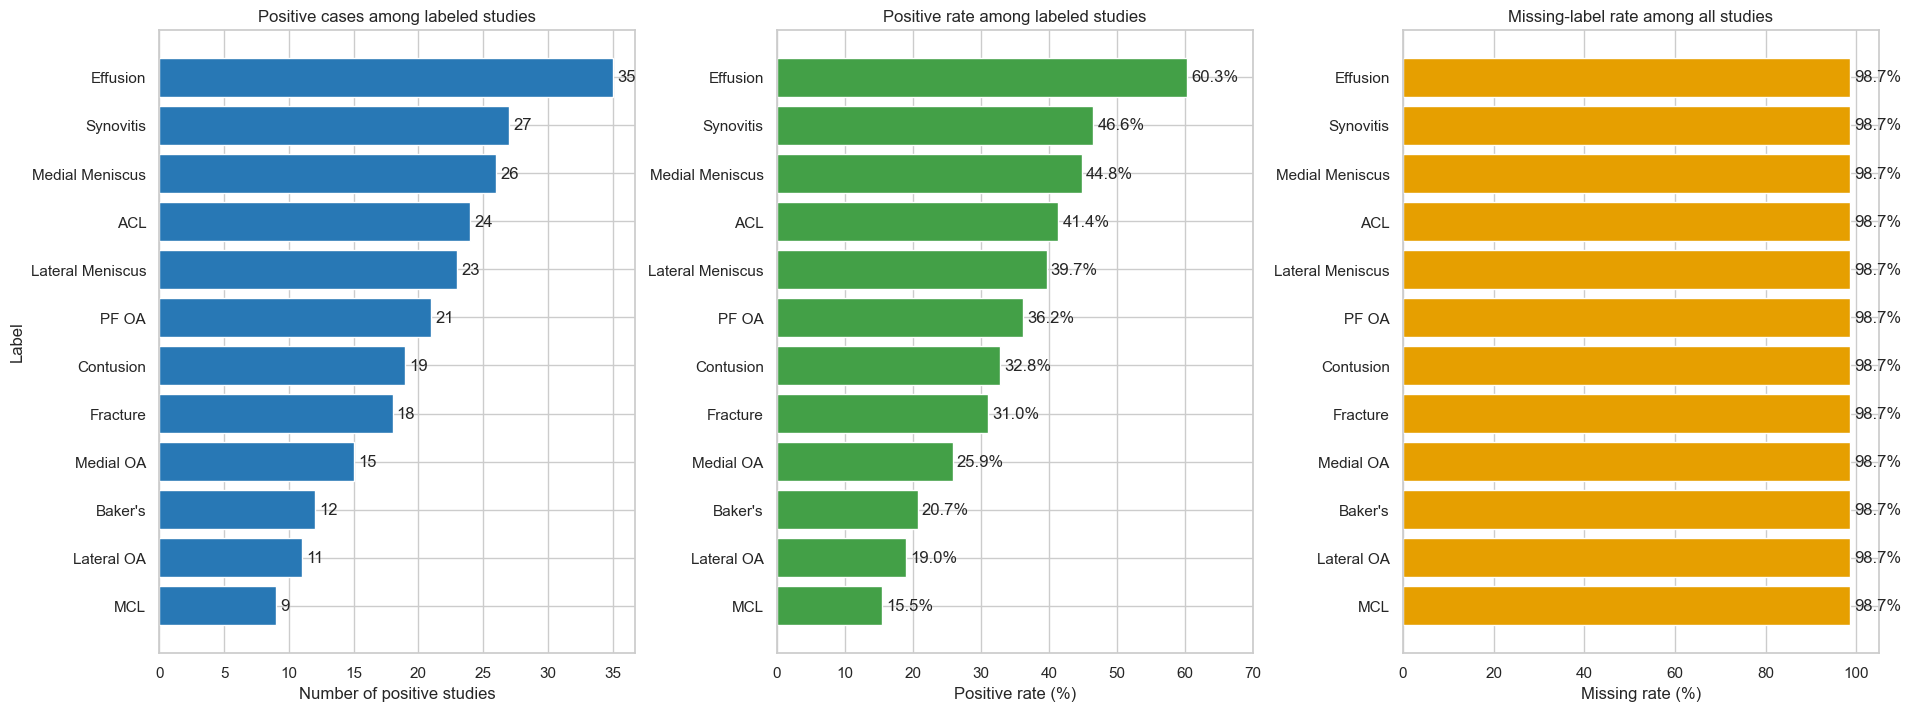

In [4]:
plot_data = label_summary.sort_values("阳性率", ascending=True)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(19, 7),
    constrained_layout=True,
)

# 阳性病例数
bars = axes[0].barh(
    plot_data.index,
    plot_data["阳性数"],
    color="#2878B5",
)
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Positive cases among labeled studies")
axes[0].set_xlabel("Number of positive studies")
axes[0].set_ylabel("Label")

# 人工标签病例中的阳性率
bars = axes[1].barh(
    plot_data.index,
    plot_data["阳性率"] * 100,
    color="#43A047",
)
axes[1].bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in plot_data["阳性率"] * 100],
    padding=3,
)
axes[1].set_title("Positive rate among labeled studies")
axes[1].set_xlabel("Positive rate (%)")
axes[1].set_xlim(0, 70)
axes[1].set_ylabel("")

# 全部训练病例中的标签缺失率
bars = axes[2].barh(
    plot_data.index,
    plot_data["缺失率"] * 100,
    color="#E69F00",
)
axes[2].bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in plot_data["缺失率"] * 100],
    padding=3,
)
axes[2].set_title("Missing-label rate among all studies")
axes[2].set_xlabel("Missing rate (%)")
axes[2].set_xlim(0, 105)
axes[2].set_ylabel("")

plt.show()

### 标签分布结论

1. 4,407个训练病例中只有58个病例具有人工标签，标签缺失率达到98.68%。缺失发生在病例级：一个病例要么拥有全部12类标签，要么全部缺失。

2. 人工标注病例中存在明显的类别不平衡。Effusion阳性率最高，为60.3%；MCL阳性率最低，为15.5%，仅有9个阳性病例。

3. 标签缺失不能填充为0。未标注病例不能直接作为12类阴性病例参与监督训练，后续必须使用标签mask，或从报告中构造经过质量验证的弱标签。

4. 只有58个人工标注病例，任何单次训练集—验证集随机划分都会非常不稳定。尤其MCL只有9个阳性病例，后续必须采用固定的病例级多标签分层交叉验证，并检查每折每类阳性数。

5. 阳性率是基于58个人工标注病例计算的，不能解释为全部4,407个训练病例中的真实患病率，因为人工标注病例可能并非随机抽样。

## 病例与MRI序列分布

本节分析每个病例包含多少个MRI序列，以及Sagittal、Coronal和Axial三个解剖平面的覆盖情况。

In [5]:
series_per_study = (
    train_series
    .groupby(id_col)
    .agg(
        序列数=("SeriesInstanceUID", "nunique"),
    )
    .reset_index()
)

display(series_per_study["序列数"].describe())

assert len(series_per_study) == len(train)
assert series_per_study[id_col].is_unique

count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
Name: 序列数, dtype: float64

### 平均值的意义
它表示平均每个研究（Study）包含多少个图像序列（Series）。

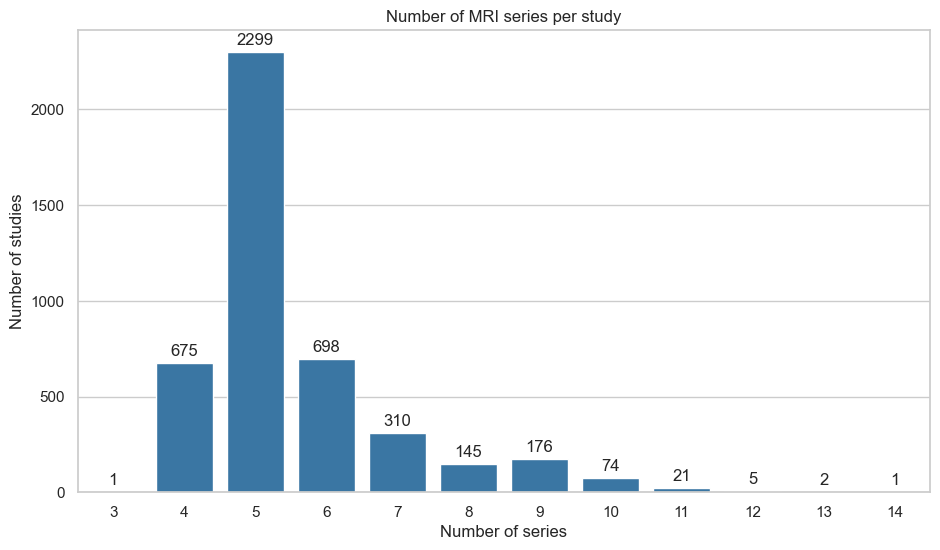

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.countplot(
    data=series_per_study,
    x="序列数",
    color="#2878B5",
    ax=ax,
)

ax.bar_label(ax.containers[0], padding=3)
ax.set_title("Number of MRI series per study")
ax.set_xlabel("Number of series")
ax.set_ylabel("Number of studies")

plt.show()

In [7]:
plane_order = ["Sagittal", "Coronal", "Axial"]

plane_by_study = pd.crosstab(
    train_series[id_col],
    train_series["Anatomical_Plane"],
).reindex(columns=plane_order, fill_value=0)

plane_presence = plane_by_study.gt(0)

plane_summary = pd.DataFrame({
    "序列数": (
        train_series["Anatomical_Plane"]
        .value_counts()
        .reindex(plane_order)
    ),
    "覆盖病例数": plane_presence.sum().reindex(plane_order),
    "覆盖率": plane_presence.mean().reindex(plane_order),
})

display(
    plane_summary.style.format({
        "覆盖率": "{:.2%}",
    })
)

assert plane_presence.all(axis=1).all()

,序列数,覆盖病例数,覆盖率
Anatomical_Plane,,,
Sagittal,9864,4407,100.00%
Coronal,8609,4407,100.00%
Axial,5898,4407,100.00%


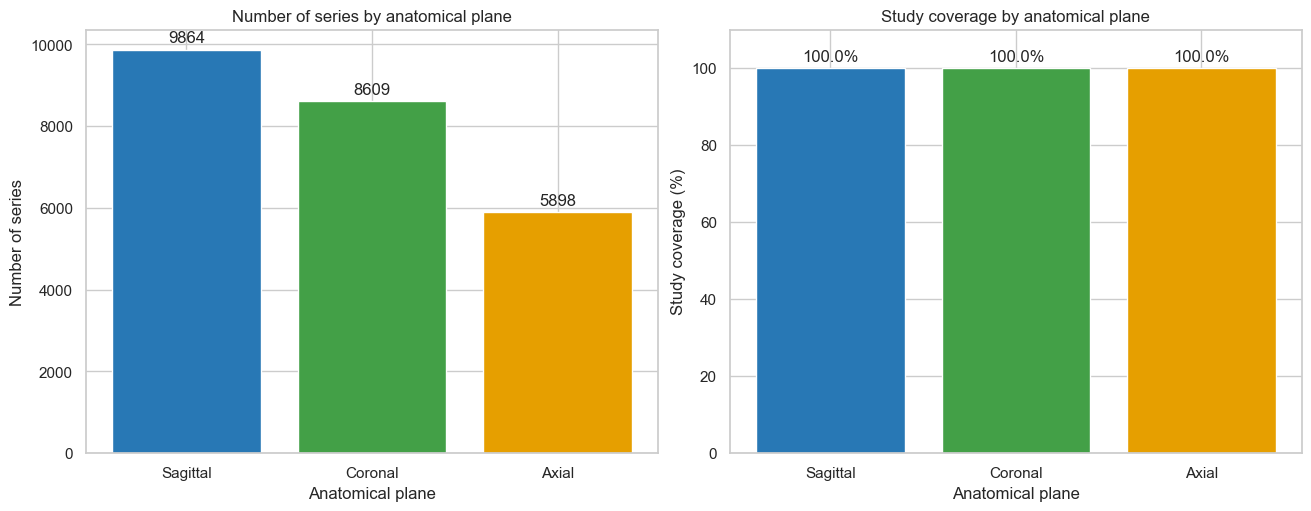

In [8]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
    constrained_layout=True,
)

bars = axes[0].bar(
    plane_summary.index,
    plane_summary["序列数"],
    color=["#2878B5", "#43A047", "#E69F00"],
)
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Number of series by anatomical plane")
axes[0].set_xlabel("Anatomical plane")
axes[0].set_ylabel("Number of series")

bars = axes[1].bar(
    plane_summary.index,
    plane_summary["覆盖率"] * 100,
    color=["#2878B5", "#43A047", "#E69F00"],
)
axes[1].bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in plane_summary["覆盖率"] * 100],
    padding=3,
)
axes[1].set_title("Study coverage by anatomical plane")
axes[1].set_xlabel("Anatomical plane")
axes[1].set_ylabel("Study coverage (%)")
axes[1].set_ylim(0, 110)

plt.show()

### 病例与序列分布结论

1. 每个病例包含3–14个MRI序列，中位数为5个，说明病例之间的序列数量并不固定。后续模型需要采用序列采样、池化或病例级聚合，而不能依赖固定序列数。

2. 每病例5个序列最常见，共2,299例。大多数病例包含4–6个序列，少数病例拥有10个以上序列，应在DICOM阶段检查这些极端病例是否包含重复序列或特殊扫描协议。

3. 所有4,407个训练病例都同时覆盖Sagittal、Coronal和Axial三个解剖平面，因此后续可以比较单平面模型，并研究三平面融合。

4. Sagittal序列总数最多，Axial序列总数最少，但三个平面的病例覆盖率都是100%。序列总数不同不代表病例覆盖率不同，而是每个病例在不同平面上拥有的序列数量不同。

## 标签共现与相关性

本节只使用58个人工标注病例，分析不同异常同时出现的次数，以及二元标签之间的Phi相关系数。

In [9]:
labeled_train = train.loc[
    fully_labeled,
    [id_col] + label_cols,
].copy()

label_matrix = labeled_train[label_cols].astype(int)

# 两个标签同时为1的病例数
co_occurrence = label_matrix.T @ label_matrix

# 对二元变量，Pearson相关系数等价于Phi相关系数
label_correlation = label_matrix.corr()

assert len(labeled_train) == 58
assert co_occurrence.shape == (12, 12)
assert label_correlation.shape == (12, 12)

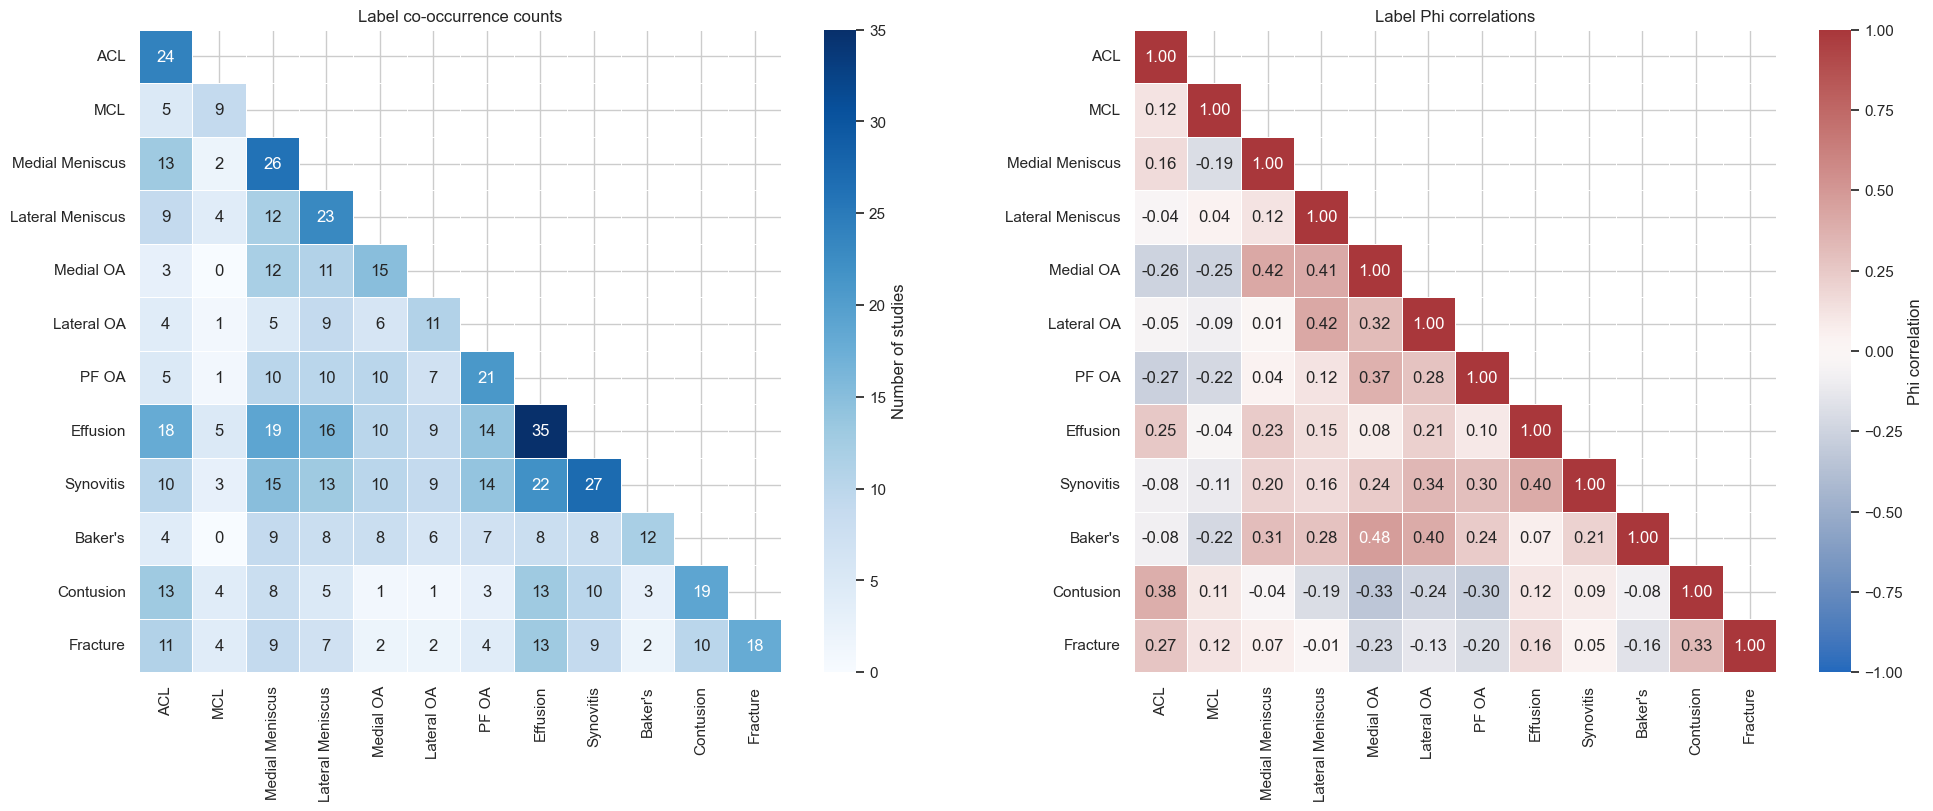

In [10]:
upper_triangle = np.triu(
    np.ones_like(co_occurrence, dtype=bool),
    k=1,
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(20, 8),
    constrained_layout=True,
)

sns.heatmap(
    co_occurrence,
    mask=upper_triangle,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Number of studies"},
    ax=axes[0],
)
axes[0].set_title("Label co-occurrence counts")

sns.heatmap(
    label_correlation,
    mask=upper_triangle,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Phi correlation"},
    ax=axes[1],
)
axes[1].set_title("Label Phi correlations")

plt.show()

In [11]:
pair_records = []

for i, label_a in enumerate(label_cols):
    for label_b in label_cols[i + 1:]:
        pair_records.append({
            "标签A": label_a,
            "标签B": label_b,
            "共现病例数": int(co_occurrence.loc[label_a, label_b]),
            "Phi相关系数": label_correlation.loc[label_a, label_b],
        })

label_pairs = pd.DataFrame(pair_records)

display(
    label_pairs
    .sort_values(
        ["共现病例数", "Phi相关系数"],
        ascending=False,
    )
    .head(10)
    .style.format({
        "Phi相关系数": "{:.3f}",
    })
)

,标签A,标签B,共现病例数,Phi相关系数
56,Effusion,Synovitis,22,0.403
25,Medial Meniscus,Effusion,19,0.235
6,ACL,Effusion,18,0.252
33,Lateral Meniscus,Effusion,16,0.153
26,Medial Meniscus,Synovitis,15,0.201
52,PF OA,Synovitis,14,0.304
51,PF OA,Effusion,14,0.097
9,ACL,Contusion,13,0.383
59,Effusion,Fracture,13,0.163
34,Lateral Meniscus,Synovitis,13,0.162


### 标签共现结论

1. Effusion与Synovitis共现最多，共22例，Phi相关系数约为0.40。这种关系具有一定临床合理性，但不能仅凭58个病例得出稳定的总体结论。

2. 共现次数和相关系数表达不同含义。Effusion本身阳性率较高，因此容易与多个标签产生较高的共现次数；Phi相关系数还会考虑两个标签各自的阳性率。

3. ACL与Contusion具有较明显的正相关，可能反映急性损伤相关模式；半月板异常与同侧OA也表现出一定正相关。

4. 人工标注样本只有58例，部分标签的阳性病例不足15例，因此相关系数可能对少数病例非常敏感。这些结果适合用于提出假设和检查分层效果，不适合解释为因果关系。

5. 后续建立交叉验证时，不仅要平衡单个标签，还应检查常见标签组合是否过度集中在某一个fold。

## 扫描协议分析

本节分析Anatomical Plane、Fluid Sensitive和Fat Suppression之间的关系，并检查不同协议在病例中的覆盖情况。

In [12]:
protocol_columns = [
    "Fluid_Sensitive",
    "Fat_Suppression",
]

for column in protocol_columns:
    print(column, sorted(train_series[column].unique()))
    assert set(train_series[column].unique()).issubset({0, 1})

train_protocol_match = (
    train_series["Fluid_Sensitive"]
    == train_series["Fat_Suppression"]
)

test_protocol_match = (
    test_series["Fluid_Sensitive"]
    == test_series["Fat_Suppression"]
)

print(
    "训练集两个字段完全一致：",
    train_protocol_match.all(),
)

print(
    "示例测试集两个字段完全一致：",
    test_protocol_match.all(),
)

print(
    "训练集不一致序列数：",
    (~train_protocol_match).sum(),
)

Fluid_Sensitive [np.int64(0), np.int64(1)]
Fat_Suppression [np.int64(0), np.int64(1)]
训练集两个字段完全一致： True
示例测试集两个字段完全一致： True
训练集不一致序列数： 0


In [13]:
plane_order = ["Sagittal", "Coronal", "Axial"]

protocol_table = pd.crosstab(
    index=train_series["Anatomical_Plane"],
    columns=[
        train_series["Fluid_Sensitive"],
        train_series["Fat_Suppression"],
    ],
).reindex(plane_order)

protocol_table.columns = [
    f"Fluid={fluid}, Fat={fat}"
    for fluid, fat in protocol_table.columns
]

protocol_percentage = (
    protocol_table
    .div(protocol_table.sum(axis=1), axis=0)
    * 100
)

display(protocol_table)

display(
    protocol_percentage.style.format("{:.2f}%")
)

,"Fluid=0, Fat=0","Fluid=1, Fat=1"
Anatomical_Plane,,
Sagittal,5197,4667
Coronal,3985,4624
Axial,1179,4719


,"Fluid=0, Fat=0","Fluid=1, Fat=1"
Anatomical_Plane,,
Sagittal,52.69%,47.31%
Coronal,46.29%,53.71%
Axial,19.99%,80.01%


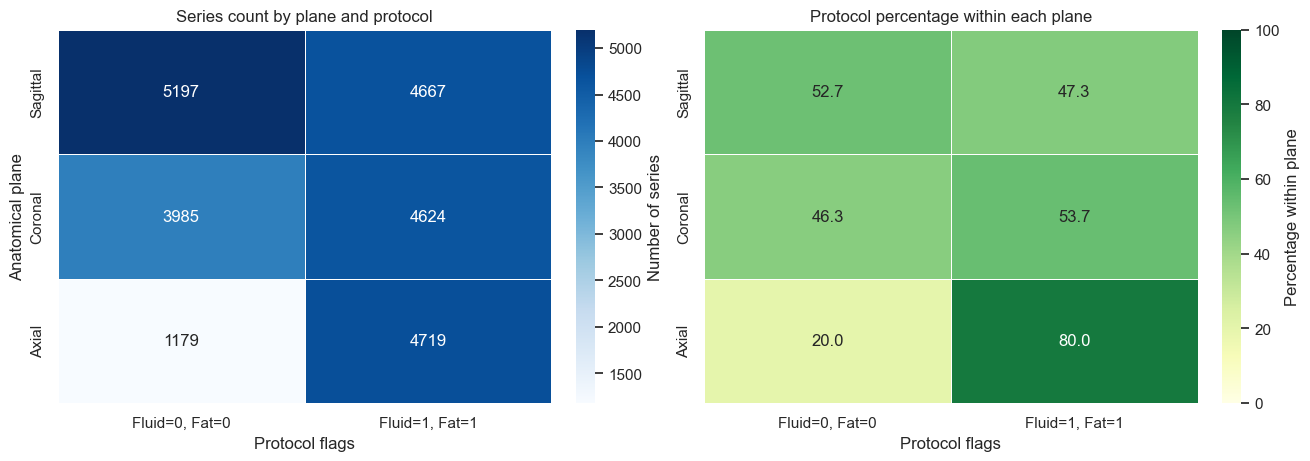

In [14]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 4.5),
    constrained_layout=True,
)

sns.heatmap(
    protocol_table,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Number of series"},
    ax=axes[0],
)
axes[0].set_title("Series count by plane and protocol")
axes[0].set_xlabel("Protocol flags")
axes[0].set_ylabel("Anatomical plane")

sns.heatmap(
    protocol_percentage,
    annot=True,
    fmt=".1f",
    cmap="YlGn",
    linewidths=0.5,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Percentage within plane"},
    ax=axes[1],
)
axes[1].set_title("Protocol percentage within each plane")
axes[1].set_xlabel("Protocol flags")
axes[1].set_ylabel("")

plt.show()

In [15]:
series_protocol = train_series.copy()

series_protocol["Protocol"] = np.where(
    series_protocol["Fluid_Sensitive"].eq(1),
    "Fluid=1, Fat=1",
    "Fluid=0, Fat=0",
)

protocol_study_coverage = (
    series_protocol
    .groupby(["Anatomical_Plane", "Protocol"])[id_col]
    .nunique()
    .unstack(fill_value=0)
    .reindex(plane_order)
)

display(protocol_study_coverage)

Protocol,"Fluid=0, Fat=0","Fluid=1, Fat=1"
Anatomical_Plane,,
Sagittal,4266,4150
Coronal,3406,4248
Axial,857,4407


### 扫描协议结论

1. 在训练集的24,371个序列中，Fluid_Sensitive与Fat_Suppression完全一致，只出现0/0和1/1两种组合。示例测试集也具有相同现象。

2. 这两个字段在当前数据中没有提供独立信息。建模时可以保留原始字段用于数据审计，但如果这种关系在隐藏测试数据中继续成立，同时使用两个embedding会造成信息重复。

3. Axial序列明显以Fluid=1、Fat=1协议为主，占Axial序列的80.01%；Sagittal和Coronal的两种协议分布相对均衡。

4. 所有4,407个训练病例都至少拥有一个Fluid=1、Fat=1的Axial序列，因此这一协议可以作为后续建立标准化单序列或单平面baseline的候选输入。

5. 不同病例拥有的协议组合和序列数量仍然不完全相同，因此后续数据管线需要处理可变数量的序列，不能依赖固定槽位。

## 人工标注与无人工标签病例比较

本节比较两组病例的序列数量、平面组成、扫描协议和报告长度，判断人工标签是否可能存在选择偏差。

In [16]:
study_features = train[
    [id_col, report_col]
].copy()

study_features["label_group"] = np.where(
    fully_labeled,
    "Manual labels",
    "Report only",
)

study_features["report_chars"] = (
    study_features[report_col]
    .fillna("")
    .str.len()
)

study_features["report_words"] = (
    study_features[report_col]
    .fillna("")
    .str.split()
    .str.len()
)

series_features = (
    train_series
    .groupby(id_col)
    .agg(
        series_count=("SeriesInstanceUID", "nunique"),
        fluid_fat_ratio=("Fluid_Sensitive", "mean"),
    )
    .reset_index()
)

plane_features = (
    pd.crosstab(
        train_series[id_col],
        train_series["Anatomical_Plane"],
    )
    .reindex(columns=plane_order, fill_value=0)
    .rename(columns={
        "Sagittal": "sagittal_count",
        "Coronal": "coronal_count",
        "Axial": "axial_count",
    })
    .reset_index()
)

study_features = (
    study_features
    .merge(series_features, on=id_col, how="left")
    .merge(plane_features, on=id_col, how="left")
)

display(study_features.head())

print(study_features["label_group"].value_counts())

,StudyInstanceUID,Report,label_group,report_chars,report_words,series_count,fluid_fat_ratio,sagittal_count,coronal_count,axial_count
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,Report only,322,44,5,0.6,2,2,1
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,Report only,245,35,5,0.6,2,2,1
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,Report only,1414,210,5,0.6,2,2,1
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",Report only,1027,140,10,0.4,3,4,3
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,Report only,1195,162,5,0.8,2,1,2


label_group
Report only      4349
Manual labels      58
Name: count, dtype: int64


In [17]:
comparison_features = [
    "series_count",
    "sagittal_count",
    "coronal_count",
    "axial_count",
    "fluid_fat_ratio",
    "report_chars",
    "report_words",
]

comparison_summary = (
    study_features
    .groupby("label_group")[comparison_features]
    .agg(["mean", "median", "std"])
    .T
)

display(
    comparison_summary.style.format("{:.2f}")
)

In [18]:
def calculate_smd(data, feature):
    labeled = data.loc[
        data["label_group"].eq("Manual labels"),
        feature,
    ]

    unlabeled = data.loc[
        data["label_group"].eq("Report only"),
        feature,
    ]

    pooled_std = np.sqrt(
        (labeled.var(ddof=1) + unlabeled.var(ddof=1)) / 2
    )

    return (labeled.mean() - unlabeled.mean()) / pooled_std


smd_values = pd.Series(
    {
        feature: calculate_smd(study_features, feature)
        for feature in comparison_features
    },
    name="SMD",
).sort_values()

display(smd_values.to_frame().style.format("{:.3f}"))

,SMD
fluid_fat_ratio,-0.012
axial_count,0.089
coronal_count,0.128
sagittal_count,0.171
series_count,0.187
report_chars,0.285
report_words,0.313


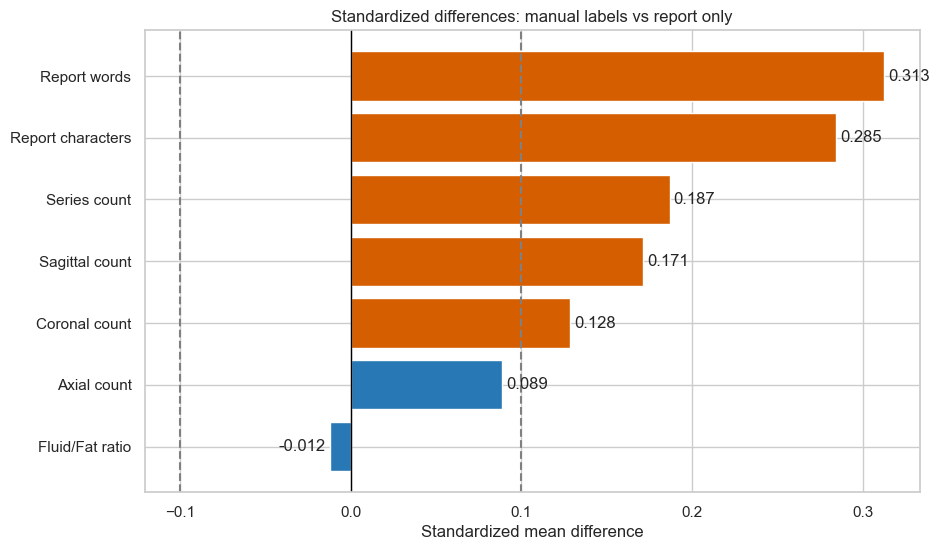

In [19]:
feature_names = {
    "series_count": "Series count",
    "sagittal_count": "Sagittal count",
    "coronal_count": "Coronal count",
    "axial_count": "Axial count",
    "fluid_fat_ratio": "Fluid/Fat ratio",
    "report_chars": "Report characters",
    "report_words": "Report words",
}

smd_plot = smd_values.rename(index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "#D55E00" if abs(value) >= 0.1 else "#2878B5"
    for value in smd_plot
]

bars = ax.barh(
    smd_plot.index,
    smd_plot.values,
    color=colors,
)

ax.bar_label(
    bars,
    labels=[f"{value:.3f}" for value in smd_plot],
    padding=3,
)

ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.1, color="gray", linestyle="--")
ax.axvline(-0.1, color="gray", linestyle="--")

ax.set_title("Standardized differences: manual labels vs report only")
ax.set_xlabel("Standardized mean difference")
ax.set_ylabel("")

plt.show()

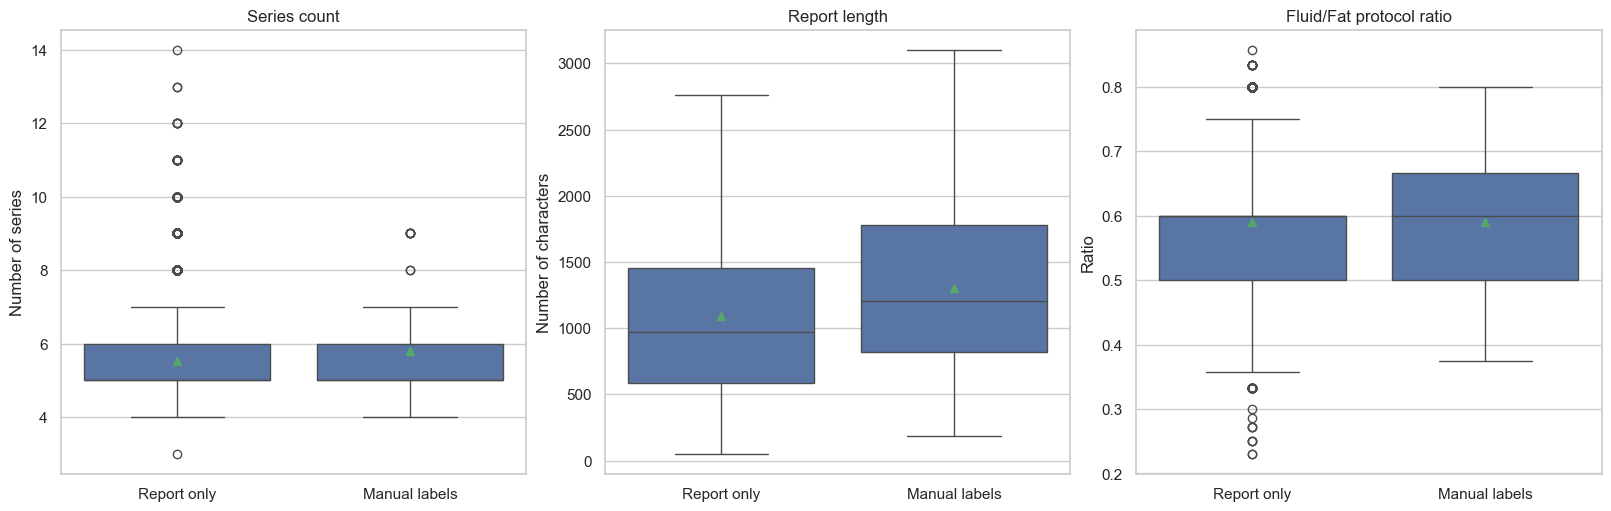

In [20]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5),
    constrained_layout=True,
)

sns.boxplot(
    data=study_features,
    x="label_group",
    y="series_count",
    showmeans=True,
    ax=axes[0],
)
axes[0].set_title("Series count")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of series")

sns.boxplot(
    data=study_features,
    x="label_group",
    y="report_chars",
    showmeans=True,
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Report length")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of characters")

sns.boxplot(
    data=study_features,
    x="label_group",
    y="fluid_fat_ratio",
    showmeans=True,
    ax=axes[2],
)
axes[2].set_title("Fluid/Fat protocol ratio")
axes[2].set_xlabel("")
axes[2].set_ylabel("Ratio")

plt.show()

### 人工标签缺失机制结论

1. 人工标注病例平均包含5.79个序列，无人工标签病例平均包含5.53个序列。差异不大，但SMD约为0.19，说明两组并非完全一致。

2. 人工标注病例的报告明显更长：平均约1,305个字符和179个词；无人工标签病例平均约1,095个字符和147个词。报告长度的SMD约为0.29–0.31，是目前观察到最明显的组间差异。

3. 两组的Fluid Sensitive/Fat Suppression协议比例几乎相同，SMD接近0，暂未发现明显的协议选择偏差。

4. 人工标签可能不是从全部训练病例中完全随机抽取的，尤其报告长度与是否获得人工标签存在一定关联。因此58个人工标注病例中的阳性率不能直接解释为全部训练数据的患病率。

5. 后续验证应只在人工标注病例上计算正式AUC，同时分析模型在报告弱标签病例上的行为，不能把两种标签来源混为同等可信度。

6. 当前CSV没有性别字段，因此阶段1无法比较两组的性别分布。若DICOM元数据包含PatientSex，应在阶段2读取影像元数据后补充检查。

## 放射学报告分析

本节分析报告的缺失、长度、语言和重复情况，为后续报告弱标签与文本建模提供依据。

In [21]:
from langdetect import detect
from langdetect import DetectorFactory
from langdetect import LangDetectException

DetectorFactory.seed = 0


def detect_language(text):
    text = str(text).strip()

    if not text:
        return "unknown"

    try:
        return detect(text)
    except LangDetectException:
        return "unknown"


report_features = train[
    [id_col, report_col]
].copy()

report_features["report_chars"] = (
    report_features[report_col]
    .fillna("")
    .str.len()
)

report_features["report_words"] = (
    report_features[report_col]
    .fillna("")
    .str.split()
    .str.len()
)

report_features["language"] = (
    report_features[report_col]
    .fillna("")
    .map(detect_language)
)

print("缺失报告数：", train[report_col].isna().sum())
print("空报告数：", report_features["report_chars"].eq(0).sum())

display(
    report_features[
        ["report_chars", "report_words"]
    ].describe()
)

缺失报告数： 0
空报告数： 0


,report_chars,report_words
count,4407.000000,4407.000000
mean,1097.905605,147.543000
std,693.948925,95.329697
min,52.000000,8.000000
25%,587.500000,74.500000
50%,977.000000,129.000000
75%,1459.500000,202.000000
max,4743.000000,690.000000


In [22]:
language_counts = (
    report_features["language"]
    .value_counts()
    .rename("报告数")
    .to_frame()
)

language_counts["占比"] = (
    language_counts["报告数"]
    / len(report_features)
)

display(
    language_counts.style.format({
        "占比": "{:.2%}",
    })
)

,报告数,占比
language,,
en,1736,39.39%
es,682,15.48%
tr,546,12.39%
hr,406,9.21%
el,321,7.28%
de,262,5.95%
bg,220,4.99%
nl,153,3.47%
fr,81,1.84%


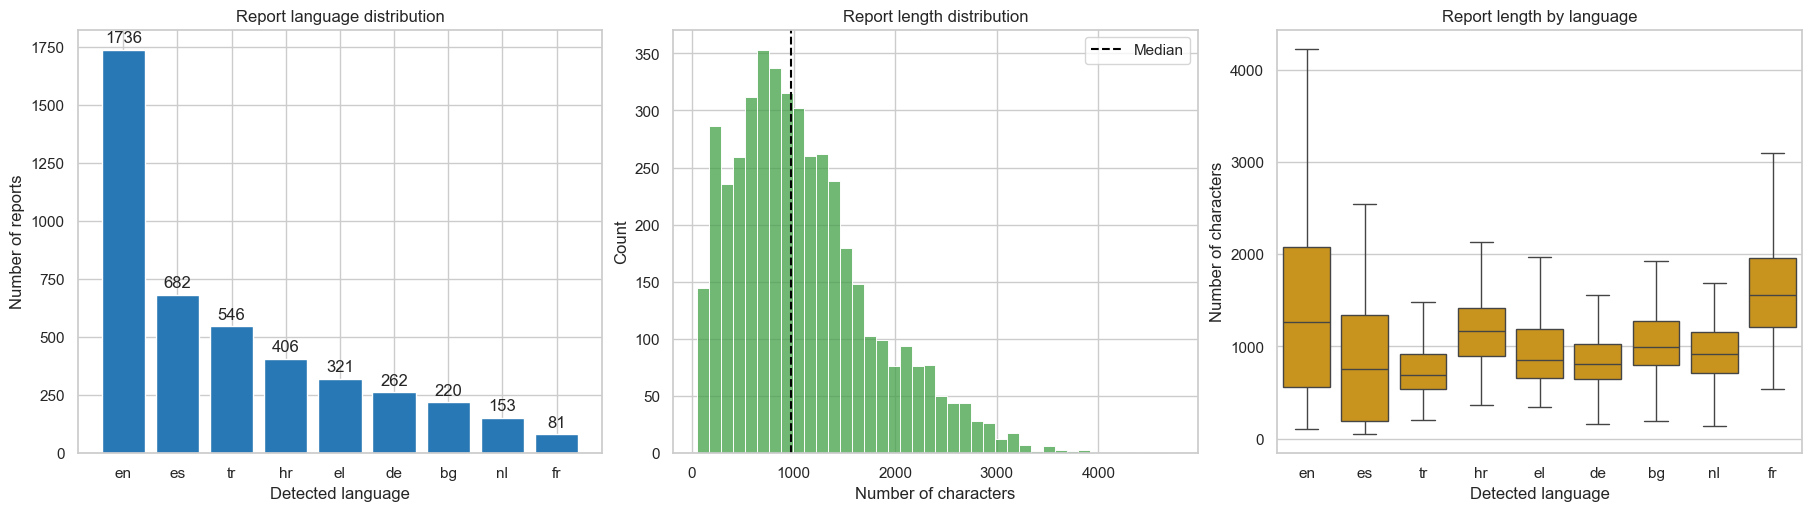

In [23]:
language_order = language_counts.index.tolist()

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
    constrained_layout=True,
)

bars = axes[0].bar(
    language_counts.index,
    language_counts["报告数"],
    color="#2878B5",
)
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Report language distribution")
axes[0].set_xlabel("Detected language")
axes[0].set_ylabel("Number of reports")

sns.histplot(
    data=report_features,
    x="report_chars",
    bins=40,
    color="#43A047",
    ax=axes[1],
)
axes[1].axvline(
    report_features["report_chars"].median(),
    color="black",
    linestyle="--",
    label="Median",
)
axes[1].set_title("Report length distribution")
axes[1].set_xlabel("Number of characters")
axes[1].legend()

sns.boxplot(
    data=report_features,
    x="language",
    y="report_chars",
    order=language_order,
    showfliers=False,
    color="#E69F00",
    ax=axes[2],
)
axes[2].set_title("Report length by language")
axes[2].set_xlabel("Detected language")
axes[2].set_ylabel("Number of characters")

plt.show()

In [24]:
report_features["normalized_report"] = (
    report_features[report_col]
    .fillna("")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.casefold()
)

exact_duplicate_excess = (
    report_features[report_col]
    .duplicated()
    .sum()
)

normalized_counts = (
    report_features["normalized_report"]
    .value_counts()
)

normalized_duplicate_excess = (
    report_features["normalized_report"]
    .duplicated()
    .sum()
)

duplicate_groups = normalized_counts[
    normalized_counts.gt(1)
]

print("完全相同的重复行数（不含每组第一条）：", exact_duplicate_excess)
print("标准化后的重复行数（不含每组第一条）：", normalized_duplicate_excess)
print("重复报告组数：", len(duplicate_groups))
print("属于重复组的病例总数：", duplicate_groups.sum())

完全相同的重复行数（不含每组第一条）：

 131
标准化后的重复行数（不含每组第一条）： 150
重复报告组数： 54
属于重复组的病例总数： 204


In [25]:
duplicate_report_summary = (
    duplicate_groups
    .rename("重复次数")
    .reset_index()
    .rename(columns={
        "normalized_report": "标准化报告",
    })
)

duplicate_report_summary["报告预览"] = (
    duplicate_report_summary["标准化报告"]
    .str.slice(0, 140)
)

display(
    duplicate_report_summary[
        ["重复次数", "报告预览"]
    ].head(10)
)

,重复次数,报告预览
0,37,diz eklemi içi sıvı miktarı normal. çapraz ve ...
1,14,técnica: rmn de la rodilla. resultados: pinzam...
2,12,técnica: rmn de la rodilla. resultados: sin an...
3,7,findings: fluid: no joint effusion. no poplite...
4,6,technique: mri of the knee. acl normal. mcl no...
5,5,técnica: rmn de la rodilla. resultados: sin an...
6,5,"sol di̇z mrg. tetkik protokolü: çok düzlemli, ..."
7,5,técnica: rmn de la rodilla. resultados: rotura...
8,5,technique: mri of the knee. acl normal. mcl no...
9,5,técnica: rmn de la rodilla. resultados: síndro...


In [26]:
language_audit = (
    report_features
    .groupby("language", group_keys=False)
    .sample(n=2, random_state=2026)
    .copy()
)

language_audit["报告预览"] = (
    language_audit[report_col]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 180)
)

display(
    language_audit[
        ["language", "报告预览"]
    ].sort_values("language")
)

,language,报告预览
2760,bg,МР находка: Няма МР данни за ставен излив. Нал...
1919,bg,МР находка: Няма МР данни за ставен излив. Кос...
1019,de,Erhaltene Artikulation im rechten Kniegelenk. ...
2833,de,Mediales Kompartiment: Zysten an der tibialen ...
447,el,"ΤΕΧΝΙΚΗ: Η εξέταση έγινε µε ακολουθίες PD FS, ..."
799,el,ΤΕΧΝΙΚΗ: Η εξέταση πραγματοποιήθηκε με ακολουθ...
2379,en,FINDINGS: There is a large knee joint effusion...
4034,en,Exam Type: MRI KNEE RIGHT WO CONTRAST Exam Dat...
2459,es,Antecedentes Clínicos: Gonalgia derecha. Halla...
101,es,Antecedentes Clínicos: Obs. Lesión meniscal. H...


### 报告语言、长度与重复结论

1. 4,407个训练病例全部具有非空报告，因此报告可以作为覆盖整个训练集的弱监督来源。

2. 报告长度差异较大，字符数从52到4,743不等，中位数为977。文本模型需要支持可变长度输入，并制定截断或分段策略。

3. 数据包含9种检测语言，英语占39.39%，没有任何一种语言占全部报告的一半以上。因此只使用英语规则或英语文本模型会丢失大量训练数据。

4. 标准化后发现54组重复报告模板，共涉及204个病例。若训练报告文本模型，随机划分可能把同一模板分到训练集和验证集，造成文本验证分数虚高。

5. 语言识别结果是自动推断，不应直接当作人工真值。后续应抽查样本，并记录容易混淆的语言或短报告。

6. 报告没有提及某种异常不能自动解释为阴性。下一步需要分别识别肯定、否定和不确定表达，并保留Unknown状态。

### 多语言否定与不确定表达

本节使用保守的多语言规则，统计报告中常见的否定和不确定表达。规则只判断报告是否包含表达，不判断表达所修饰的具体异常。

In [27]:
import re

expression_patterns = {
    "Negation": {
        "en": {
            "no": r"\bno\b",
            "not": r"\bnot\b",
            "without": r"\bwithout\b",
            "negative for": r"\bnegative\s+for\b",
            "absence of": r"\babsence\s+of\b",
            "none": r"\bnone\b",
        },
        "es": {
            "no": r"\bno\b",
            "sin": r"\bsin\b",
            "ausencia": r"\bausencia\b",
            "ningún/ninguna": r"\bning[uú]n\w*\b",
        },
        "tr": {
            "yok/yoktur": r"\byok(?:tur)?\b",
            "izlenmedi": r"\bizlenmedi\b",
            "saptanmadı variants": (
                r"\bsaptanmad[ıi]\b|"
                r"\bsaptanmam[ıi]şt[ıi]r\b"
            ),
        },
        "hr": {
            "nema": r"\bnema\b",
            "nije": r"\bnije\b",
            "bez": r"\bbez\b",
            "ne vidi": r"\bne\s+vidi\w*\b",
        },
        "el": {
            "δεν": r"\bδεν\b",
            "χωρίς": r"\bχωρίς\b",
            "απουσία": r"\bαπουσία\b",
        },
        "de": {
            "kein variants": r"\bkein\w*\b",
            "nicht": r"\bnicht\b",
            "ohne": r"\bohne\b",
        },
        "bg": {
            "няма": r"\bняма\b",
            "не се": r"\bне\s+се\b",
            "без": r"\bбез\b",
            "липсва": r"\bлипсва\w*\b",
        },
        "nl": {
            "geen": r"\bgeen\b",
            "niet": r"\bniet\b",
            "zonder": r"\bzonder\b",
            "afwezig": r"\bafwezig\w*\b",
        },
        "fr": {
            "pas de": r"\bpas\s+de\b",
            "sans": r"\bsans\b",
            "absence": r"\babsence\b",
            "aucun variants": r"\baucun\w*\b",
        },
    },
    "Uncertainty": {
        "en": {
            "suggest variants": r"\bsuggest\w*\b",
            "suspicious": r"\bsuspicious\b",
            "likely": r"\blikely\b",
            "possible variants": r"\bpossibl\w*\b",
            "probable variants": r"\bprobabl\w*\b",
            "cannot exclude": r"\b(?:cannot|can't)\s+exclude\b",
            "may represent": r"\bmay\s+represent\b",
            "could represent": r"\bcould\s+represent\b",
        },
        "es": {
            "posible variants": r"\bposibl\w*\b",
            "probable variants": r"\bprobabl\w*\b",
            "sugiere/sugestivo": (
                r"\bsugier\w*\b|"
                r"\bsugest\w*\b"
            ),
            "sospecha variants": r"\bsospech\w*\b",
            "no se puede descartar": (
                r"\bno\s+se\s+puede\s+descartar\b"
            ),
        },
        "tr": {
            "olabilir": r"\bolabilir\b",
            "şüpheli": r"\bşüpheli\b",
            "düşündür variants": r"\bdüşündür\w*\b",
            "muhtemel": r"\bmuhtemel\b",
        },
        "hr": {
            "moguće": r"\bmoguće\b",
            "vjerojatno": r"\bvjerojatno\b",
            "suspekt variants": r"\bsuspekt\w*\b",
            "ne može se isključiti": (
                r"\bne\s+može\s+se\s+isključiti\b"
            ),
        },
        "el": {
            "πιθαν variants": r"\bπιθαν\w*\b",
            "ύποπτ variants": r"\b[ύυ]ποπτ\w*\b",
        },
        "de": {
            "möglich variants": r"\bmöglich\w*\b",
            "wahrscheinlich variants": r"\bwahrscheinlich\w*\b",
            "verdacht variants": r"\bverdacht\w*\b",
            "nicht auszuschließen": (
                r"\bnicht\s+auszuschließen\b"
            ),
        },
        "bg": {
            "възмож variants": r"\bвъзмож\w*\b",
            "вероят variants": r"\bвероят\w*\b",
            "съмнение variants": r"\bсъмнен\w*\b",
        },
        "nl": {
            "mogelijk variants": r"\bmogelijk\w*\b",
            "waarschijnlijk variants": r"\bwaarschijnlijk\w*\b",
            "verdacht variants": r"\bverdacht\w*\b",
            "niet uit te sluiten": (
                r"\bniet\s+uit\s+te\s+sluiten\b"
            ),
        },
        "fr": {
            "possible variants": r"\bpossibl\w*\b",
            "probable variants": r"\bprobabl\w*\b",
            "suspect variants": r"\bsuspect\w*\b",
        },
    },
}

In [28]:
expression_records = []

report_flags = {
    category: pd.Series(
        False,
        index=report_features.index,
    )
    for category in expression_patterns
}

for category, language_rules in expression_patterns.items():
    for language, expressions in language_rules.items():
        language_mask = report_features["language"].eq(language)

        for expression, pattern in expressions.items():
            matches = (
                language_mask
                & report_features["normalized_report"].str.contains(
                    pattern,
                    regex=True,
                    na=False,
                )
            )

            report_flags[category] |= matches

            expression_records.append({
                "类型": category,
                "语言": language,
                "表达": expression,
                "报告数": int(matches.sum()),
            })

report_features["has_negation"] = report_flags["Negation"]
report_features["has_uncertainty"] = report_flags["Uncertainty"]

expression_summary = pd.DataFrame(expression_records)

flag_summary = pd.DataFrame({
    "报告数": [
        report_features["has_negation"].sum(),
        report_features["has_uncertainty"].sum(),
    ],
    "占比": [
        report_features["has_negation"].mean(),
        report_features["has_uncertainty"].mean(),
    ],
}, index=["Negation", "Uncertainty"])

display(
    flag_summary.style.format({
        "占比": "{:.2%}",
    })
)

,报告数,占比
Negation,3391,76.95%
Uncertainty,1013,22.99%


In [29]:
display(
    expression_summary
    .query("报告数 > 0")
    .sort_values(
        ["类型", "报告数"],
        ascending=[True, False],
    )
    .groupby("类型", group_keys=False)
    .head(15)
)

,类型,语言,表达,报告数
0,Negation,en,no,1561
2,Negation,en,without,623
1,Negation,en,not,586
7,Negation,es,sin,371
6,Negation,es,no,336
10,Negation,tr,yok/yoktur,313
15,Negation,hr,bez,302
20,Negation,de,kein variants,190
5,Negation,en,none,164
12,Negation,tr,saptanmadı variants,157


In [30]:
expression_overlap = pd.crosstab(
    report_features["has_negation"],
    report_features["has_uncertainty"],
)

expression_overlap.index.name = "Has negation"
expression_overlap.columns.name = "Has uncertainty"

display(expression_overlap)

Has uncertainty,False,True
Has negation,,
False,880,136
True,2514,877


In [31]:
audit_candidates = pd.concat([
    report_features.loc[
        report_features["has_negation"]
    ].assign(expression_type="Negation"),

    report_features.loc[
        report_features["has_uncertainty"]
    ].assign(expression_type="Uncertainty"),
])

audit_sample = (
    audit_candidates
    .sample(
        n=min(30, len(audit_candidates)),
        random_state=2026,
    )
    .copy()
)

audit_sample["报告预览"] = (
    audit_sample[report_col]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 220)
)

display(
    audit_sample[
        [
            "expression_type",
            "language",
            "报告预览",
        ]
    ]
)

,expression_type,language,报告预览
630,Negation,fr,Interprétation : Il y a une minime quantité de...
463,Negation,en,FINDINGS: Fluid: Moderate right knee joint eff...
1913,Negation,en,Technique: MRI of the knee. ACL chronic tear.....
2468,Negation,nl,[DATE]: MR Knie Links 15ch AA: Klinische inlic...
2801,Negation,hr,"Umjerene degenerativne promjene FT zgloba, izr..."
96,Negation,en,Technique: MRI of the knee. ACL normal. MCL no...
742,Negation,de,Mediales Kompartiment: Regelrechtes Knochenmak...
3232,Uncertainty,en,"COMPARISON:None. CLINICAL HISTORY:Recent fall,..."
2316,Negation,tr,"SOL DİZ MRG. Tetkik protokolü: Çok düzlemli, ç..."
2583,Negation,es,Antecedentes Clínicos: Gonalgia derecha en est...


### 否定与不确定表达结论

1. 约76.95%的报告包含至少一个初步否定表达，约22.99%的报告包含至少一个不确定表达。放射学报告中否定和不确定措辞非常常见。

2. 有877份报告同时包含否定和不确定表达。因此不能把整份报告简单归类为Positive或Negative，必须判断表达所修饰的具体异常。

3. “报告未提及某异常”不能视为阴性；只有在词典命中明确否定表达，并确认其作用范围指向目标异常时，才可以考虑产生候选阴性弱标签。

4. “possible”“suggestive”“suspicious”等不确定表达应映射为Unknown或较低置信度，而不是强制映射为阳性或阴性。

5. 当前规则只是探索性词典，尚未处理否定作用域、双重否定、时间关系和同义词。任何报告弱标签方案都必须先进行分语言人工抽查并估计Precision和Recall。

6. 测试集不提供报告，因此报告信息只能用于训练阶段的弱标签、蒸馏或影像—文本预训练，不能成为测试推理的必需输入。

## 阶段1核心结论与建模影响

1. **病例与序列关系完整。** `train.csv`包含4,407个唯一病例，`train_series.csv`包含24,371个唯一序列；所有病例都能关联到序列。后续应始终以`StudyInstanceUID`作为不可拆分的病例单位。

2. **人工标签极少且按病例成组缺失。** 只有58个病例拥有完整的12类人工标签，其余4,349个病例的标签全部缺失，没有部分缺失病例。缺失标签不能填成0，训练代码仍应保留逐标签mask。

3. **人工标注集存在类别不平衡。** Effusion阳性最多，为35/58（60.3%）；MCL阳性最少，仅9/58（15.5%）。固定多标签分层fold后必须逐折检查每类阳性和阴性数，否则AUC可能不可计算或波动很大。

4. **标签之间存在可解释但不稳定的共现。** Effusion与Synovitis共现22例，ACL与Contusion也表现出正相关。由于样本只有58例，共现结果适合用于检查fold平衡和提出建模假设，不应解释为稳定的总体规律或因果关系。

5. **每病例序列数量可变，但三平面覆盖完整。** 每病例包含3–14个序列，中位数为5；所有病例都具有Sagittal、Coronal和Axial序列。数据管线需要支持可变数量的序列，并通过采样、池化或注意力完成病例级聚合。

6. **扫描协议字段在当前数据中冗余。** `Fluid_Sensitive`与`Fat_Suppression`在训练集和示例测试集中完全一致，只出现0/0和1/1。Axial序列中1/1协议占80.01%，且所有训练病例至少有一个此类Axial序列，可作为阶段2标准化baseline的候选输入。

7. **人工标注病例可能不是随机样本。** 人工标注组的报告更长，报告词数和字符数的SMD约为0.31和0.29；序列数SMD约为0.19。58例中的阳性率不能直接解释为全部4,407例的患病率。

8. **报告覆盖完整但高度多语言。** 全部病例都有非空报告，共检测到9种语言；英语仅占39.39%。仅使用英语规则或英语文本模型会丢失大部分弱监督数据，语言识别结果也需要分语言人工抽查。

9. **重复报告可能造成文本验证泄漏。** 标准化后发现54组重复报告模板，涉及204个病例。训练或验证报告模型时，应检查重复模板是否跨fold，并避免把模板记忆误认为文本理解能力。

10. **否定和不确定表达必须保留作用域与Unknown状态。** 约76.95%的报告包含初步否定表达，22.99%包含不确定表达，877份同时包含两者。报告未提及不等于阴性，不确定表达不应强制映射为0/1；测试时没有报告，因此文本只能用于训练阶段的弱标签、蒸馏或影像—文本预训练。

### 阶段2入口条件

阶段2先使用20–50个病例开发DICOM读取、排序和可视化模块；在随机抽查确认切片顺序、灰度、压缩解码和错误日志均可靠前，不进入模型训练。